"""
Business Strategy for the Home Credit Default Risk project.

This notebook converts predicted probabilities of default into business-facing
credit decisions. It analyses approval, manual review and decline rates, compares
threshold strategies, and estimates expected credit loss.
"""

In [2]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.config import REPORTS_DIR, PROCESSED_DATA_DIR, PROCESSED_TRAIN_FILE, ID_COLUMN

from src.decision_strategy import (
    create_decision_output,
    summarise_decision_distribution,
    summarise_decision_performance,
    create_expected_loss_table,
    summarise_expected_loss_by_decision,
    compare_threshold_strategies,
)

In [4]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

In [5]:
validation_predictions_path = REPORTS_DIR / "validation_predictions.csv"
processed_train_path = PROCESSED_DATA_DIR / PROCESSED_TRAIN_FILE

validation_predictions = pd.read_csv(validation_predictions_path)
processed_train = pd.read_csv(processed_train_path)

print("Validation predictions loaded successfully.")
print(f"Validation predictions shape: {validation_predictions.shape}")
print(f"Processed train shape: {processed_train.shape}")

Validation predictions loaded successfully.
Validation predictions shape: (61503, 4)
Processed train shape: (307511, 620)


In [6]:
validation_predictions.head()

,applicant_id,actual_default,baseline_probability_of_default,probability_of_default
0,396899,0,0.277277,0.245891
1,322041,0,0.330339,0.355527
2,220127,0,0.721323,0.846795
3,251531,0,0.385536,0.262195
4,345558,0,0.722593,0.603109


In [7]:
decision_table = create_decision_output(
    applicant_ids=validation_predictions["applicant_id"],
    probabilities=validation_predictions["probability_of_default"],
    actual_target=validation_predictions["actual_default"],
    low_risk_threshold=0.10,
    high_risk_threshold=0.30,
)

decision_table.head()

,applicant_id,probability_of_default,risk_band,recommended_decision,actual_default
0,396899,0.245891,Medium Risk,Manual Review,0
1,322041,0.355527,High Risk,Decline,0
2,220127,0.846795,High Risk,Decline,0
3,251531,0.262195,Medium Risk,Manual Review,0
4,345558,0.603109,High Risk,Decline,0


In [8]:
decision_distribution = summarise_decision_distribution(decision_table)

decision_distribution

,recommended_decision,risk_band,applicant_count,average_probability_of_default,applicant_share
0,Approve,Low Risk,6087,0.069779,0.098971
1,Manual Review,Medium Risk,23383,0.195510,0.380193
2,Decline,High Risk,32033,0.532466,0.520836


In [9]:
decision_performance = summarise_decision_performance(decision_table)

decision_performance

,recommended_decision,risk_band,applicant_count,default_count,average_probability_of_default,actual_default_rate,applicant_share,default_share
0,Approve,Low Risk,6087,61,0.069779,0.010021,0.098971,0.012286
1,Manual Review,Medium Risk,23383,592,0.195510,0.025318,0.380193,0.119235
2,Decline,High Risk,32033,4312,0.532466,0.134611,0.520836,0.868479


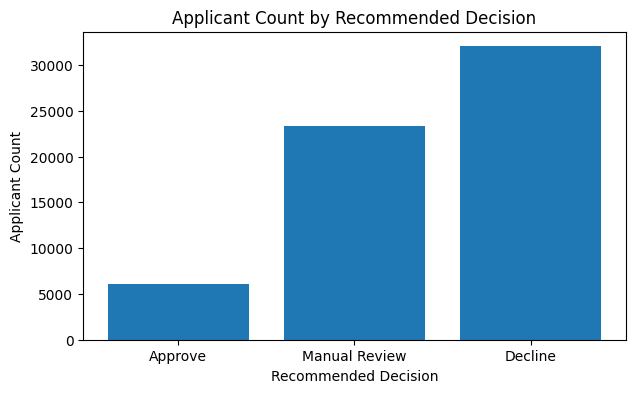

In [10]:
plt.figure(figsize=(7, 4))
plt.bar(
    decision_distribution["recommended_decision"],
    decision_distribution["applicant_count"],
)
plt.title("Applicant Count by Recommended Decision")
plt.xlabel("Recommended Decision")
plt.ylabel("Applicant Count")
plt.xticks(rotation=0)
plt.show()

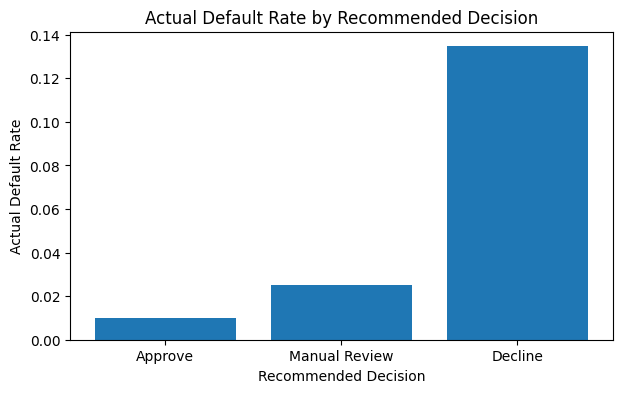

In [11]:
plt.figure(figsize=(7, 4))
plt.bar(
    decision_performance["recommended_decision"],
    decision_performance["actual_default_rate"],
)
plt.title("Actual Default Rate by Recommended Decision")
plt.xlabel("Recommended Decision")
plt.ylabel("Actual Default Rate")
plt.xticks(rotation=0)
plt.show()

In [12]:
validation_with_credit = validation_predictions.merge(
    processed_train[[ID_COLUMN, "AMT_CREDIT"]],
    left_on="applicant_id",
    right_on=ID_COLUMN,
    how="left",
)

validation_with_credit.head()

,applicant_id,actual_default,baseline_probability_of_default,probability_of_default,SK_ID_CURR,AMT_CREDIT
0,396899,0,0.277277,0.245891,396899,770292.0
1,322041,0,0.330339,0.355527,322041,364896.0
2,220127,0,0.721323,0.846795,220127,284400.0
3,251531,0,0.385536,0.262195,251531,976711.5
4,345558,0,0.722593,0.603109,345558,323194.5


In [13]:
expected_loss_table = create_expected_loss_table(
    decision_df=decision_table,
    exposure_at_default=validation_with_credit["AMT_CREDIT"],
    loss_given_default=0.45,
)

expected_loss_table.head()

,applicant_id,probability_of_default,risk_band,recommended_decision,actual_default,exposure_at_default,loss_given_default,expected_loss
0,396899,0.245891,Medium Risk,Manual Review,0,770292.0,0.45,85233.400038
1,322041,0.355527,High Risk,Decline,0,364896.0,0.45,58378.663833
2,220127,0.846795,High Risk,Decline,0,284400.0,0.45,108372.761793
3,251531,0.262195,Medium Risk,Manual Review,0,976711.5,0.45,115239.864984
4,345558,0.603109,High Risk,Decline,0,323194.5,0.45,87714.644022


In [14]:
expected_loss_summary = summarise_expected_loss_by_decision(expected_loss_table)

expected_loss_summary

,recommended_decision,risk_band,applicant_count,average_probability_of_default,total_exposure,average_exposure,total_expected_loss,average_expected_loss
0,Approve,Low Risk,6087,0.069779,3.851499e+09,632741.770084,1.205589e+08,19805.970291
1,Manual Review,Medium Risk,23383,0.195510,1.476285e+10,631349.760403,1.296050e+09,55426.999259
2,Decline,High Risk,32033,0.532466,1.815073e+10,566625.965192,4.262037e+09,133051.444300


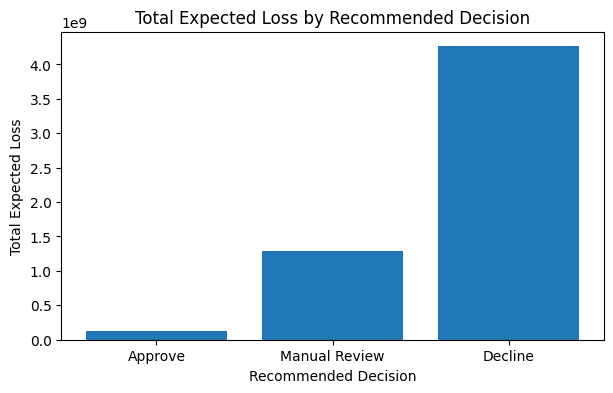

In [15]:
plt.figure(figsize=(7, 4))
plt.bar(
    expected_loss_summary["recommended_decision"],
    expected_loss_summary["total_expected_loss"],
)
plt.title("Total Expected Loss by Recommended Decision")
plt.xlabel("Recommended Decision")
plt.ylabel("Total Expected Loss")
plt.xticks(rotation=0)
plt.show()

In [16]:
threshold_strategy_comparison = compare_threshold_strategies(
    applicant_ids=validation_predictions["applicant_id"],
    probabilities=validation_predictions["probability_of_default"],
    actual_target=validation_predictions["actual_default"],
    exposure_at_default=validation_with_credit["AMT_CREDIT"],
    threshold_pairs=[
        (0.05, 0.20),
        (0.05, 0.25),
        (0.10, 0.25),
        (0.10, 0.30),
        (0.15, 0.35),
        (0.20, 0.40),
    ],
    loss_given_default=0.45,
)

threshold_strategy_comparison

,low_risk_threshold,high_risk_threshold,approval_rate,manual_review_rate,decline_rate,approved_default_rate,manual_review_default_rate,declined_default_rate,approved_expected_loss,total_expected_loss
0,0.05,0.20,0.018958,0.283856,0.697186,0.005146,0.016038,0.109121,1.262418e+07,5.678645e+09
1,0.05,0.25,0.018958,0.375835,0.605206,0.005146,0.019900,0.120869,1.262418e+07,5.678645e+09
2,0.10,0.25,0.098971,0.295823,0.605206,0.010021,0.022260,0.120869,1.205589e+08,5.678645e+09
3,0.10,0.30,0.098971,0.380193,0.520836,0.010021,0.025318,0.134611,1.205589e+08,5.678645e+09
4,0.15,0.35,0.201486,0.350178,0.448336,0.012266,0.033524,0.148364,3.443458e+08,5.678645e+09
5,0.20,0.40,0.302814,0.314147,0.383038,0.015357,0.042389,0.163851,6.579739e+08,5.678645e+09


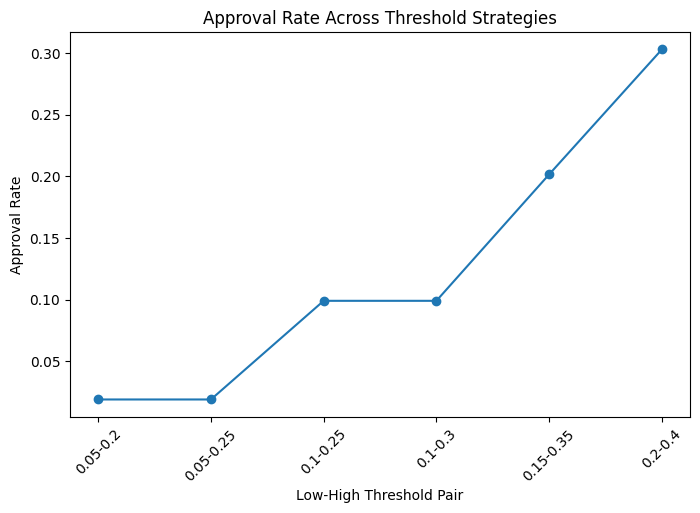

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(
    threshold_strategy_comparison["low_risk_threshold"].astype(str)
    + "-"
    + threshold_strategy_comparison["high_risk_threshold"].astype(str),
    threshold_strategy_comparison["approval_rate"],
    marker="o",
)
plt.title("Approval Rate Across Threshold Strategies")
plt.xlabel("Low-High Threshold Pair")
plt.ylabel("Approval Rate")
plt.xticks(rotation=45)
plt.show()

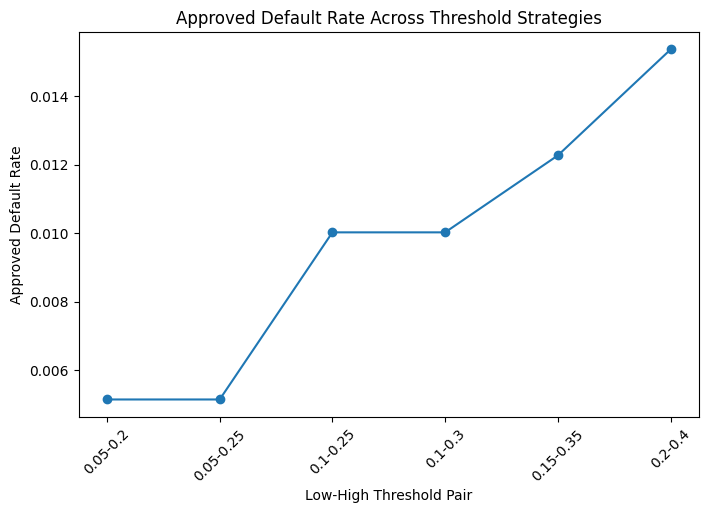

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(
    threshold_strategy_comparison["low_risk_threshold"].astype(str)
    + "-"
    + threshold_strategy_comparison["high_risk_threshold"].astype(str),
    threshold_strategy_comparison["approved_default_rate"],
    marker="o",
)
plt.title("Approved Default Rate Across Threshold Strategies")
plt.xlabel("Low-High Threshold Pair")
plt.ylabel("Approved Default Rate")
plt.xticks(rotation=45)
plt.show()

In [19]:
business_summary = pd.DataFrame(
    {
        "metric": [
            "validation_applicants",
            "average_probability_of_default",
            "actual_default_rate",
            "approval_rate",
            "manual_review_rate",
            "decline_rate",
            "total_expected_loss",
            "loss_given_default_assumption",
        ],
        "value": [
            len(decision_table),
            decision_table["probability_of_default"].mean(),
            decision_table["actual_default"].mean(),
            decision_table["recommended_decision"].eq("Approve").mean(),
            decision_table["recommended_decision"].eq("Manual Review").mean(),
            decision_table["recommended_decision"].eq("Decline").mean(),
            expected_loss_table["expected_loss"].sum(),
            0.45,
        ],
    }
)

business_summary

,metric,value
0,validation_applicants,6.150300e+04
1,average_probability_of_default,3.585653e-01
2,actual_default_rate,8.072777e-02
3,approval_rate,9.897078e-02
4,manual_review_rate,3.801928e-01
5,decline_rate,5.208364e-01
6,total_expected_loss,5.678645e+09
7,loss_given_default_assumption,4.500000e-01


In [20]:
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

decision_table.to_csv(
    REPORTS_DIR / "business_decision_table.csv",
    index=False,
)

decision_distribution.to_csv(
    REPORTS_DIR / "business_decision_distribution.csv",
    index=False,
)

decision_performance.to_csv(
    REPORTS_DIR / "business_decision_performance.csv",
    index=False,
)

expected_loss_table.to_csv(
    REPORTS_DIR / "business_expected_loss_table.csv",
    index=False,
)

expected_loss_summary.to_csv(
    REPORTS_DIR / "business_expected_loss_summary.csv",
    index=False,
)

threshold_strategy_comparison.to_csv(
    REPORTS_DIR / "business_threshold_strategy_comparison.csv",
    index=False,
)

business_summary.to_csv(
    REPORTS_DIR / "business_summary.csv",
    index=False,
)

print("Business strategy outputs saved successfully.")

Business strategy outputs saved successfully.


In [21]:
print("Business strategy analysis complete.")
print(f"Decision table saved to: {REPORTS_DIR / 'business_decision_table.csv'}")
print(f"Business summary saved to: {REPORTS_DIR / 'business_summary.csv'}")

Business strategy analysis complete.
Decision table saved to: /Users/shriyanshnautiyal/Downloads/credit-risk-modelling-home-credit/reports/business_decision_table.csv
Business summary saved to: /Users/shriyanshnautiyal/Downloads/credit-risk-modelling-home-credit/reports/business_summary.csv
